# Chapter 16 — Smoothing: Avoiding Overconfident Zero Probabilities

Chapter 15 normalized bigram count rows into conditional probability distributions.

An unsmoothed row assigns probability zero to every transition absent from the training text.

This chapter introduces **smoothing**, which reserves some probability for unseen transitions between known tokens.

By the end of this chapter, you should be able to:

- explain why zero probabilities can make a count model brittle;
- apply add-one and add-alpha smoothing;
- verify the add-alpha formula;
- smooth one row and an entire count table;
- handle a zero row without a separate row fallback;
- compare smoothing strengths and probability-mass allocation;
- generate from a smoothed bigram model; and
- explain what smoothing does not solve.

This chapter improves the count-based bigram model without using neural networks.


## Why Zero Probability Is Too Strong

Suppose the fixture contains `"c" → "a"` but never contains `"c" → "o"`.

The unsmoothed fitted model assigns $P(\text{"o"}\mid\text{"c"})=0$.

That makes the transition impossible under this model, even though `"co"` appears in ordinary words such as `come`, `cold`, and `connect`.

The zero count reflects limited observations rather than proof that the transition is impossible in the underlying language.


## Add-Alpha Smoothing

**Add-alpha smoothing** adds a positive constant $\alpha$ to every possible count before row normalization.

For count $C$, row total $R$, and vocabulary size $V$, the smoothed probability is

$$
\frac{C+\alpha}{R+\alpha V}.
$$

Setting $\alpha=1$ gives **add-one smoothing**.

Smaller positive values such as $0.1$ apply weaker smoothing.


## Reuse the Prepared Fixture

The familiar small fixture makes unseen transitions and probability changes easy to inspect.


In [1]:
prepared_text = (
    "The dog ran across the yard.\n"
    "The cat sat near the window.\n"
    "\n"
    "The dog looked at the cat!\n"
    "The cat looked back."
)

print(prepared_text)
print()
print(repr(prepared_text))

The dog ran across the yard.
The cat sat near the window.

The dog looked at the cat!
The cat looked back.

'The dog ran across the yard.\nThe cat sat near the window.\n\nThe dog looked at the cat!\nThe cat looked back.'


## Build Stable Character IDs

The sorted vocabulary defines the possible next-token columns to which smoothing can assign probability.


In [2]:
def build_character_mappings(
    text: str,
) -> tuple[list[str], dict[str, int], dict[int, str]]:
    vocabulary = sorted(set(text))
    character_to_id = {
        character: character_id for character_id, character in enumerate(vocabulary)
    }
    id_to_character = {
        character_id: character for character, character_id in character_to_id.items()
    }
    return vocabulary, character_to_id, id_to_character


character_vocabulary, character_to_id, id_to_character = build_character_mappings(
    prepared_text
)
vocabulary_size = len(character_vocabulary)

print("Vocabulary size:", vocabulary_size)
for character_id, character in enumerate(character_vocabulary):
    print(f"{character_id:>3}: {character!r}")

Vocabulary size: 22
  0: '\n'
  1: ' '
  2: '!'
  3: '.'
  4: 'T'
  5: 'a'
  6: 'b'
  7: 'c'
  8: 'd'
  9: 'e'
 10: 'g'
 11: 'h'
 12: 'i'
 13: 'k'
 14: 'l'
 15: 'n'
 16: 'o'
 17: 'r'
 18: 's'
 19: 't'
 20: 'w'
 21: 'y'


## Encode and Decode the Fixture

The exact round trip verifies the token sequence before counting transitions.


In [3]:
def encode_characters(
    text: str,
    character_to_id: dict[str, int],
) -> list[int]:
    token_ids = []
    for position, character in enumerate(text):
        if character not in character_to_id:
            raise ValueError(f"Unknown character {character!r} at position {position}.")
        token_ids.append(character_to_id[character])
    return token_ids


def decode_character_ids(
    token_ids: list[int],
    id_to_character: dict[int, str],
) -> str:
    characters = []
    for position, token_id in enumerate(token_ids):
        if token_id not in id_to_character:
            raise ValueError(f"Unknown token ID {token_id} at position {position}.")
        characters.append(id_to_character[token_id])
    return "".join(characters)


token_ids = encode_characters(prepared_text, character_to_id)
decoded_text = decode_character_ids(token_ids, id_to_character)

assert decoded_text == prepared_text
print("Token count:", len(token_ids))
print("First 80 token IDs:", token_ids[:80])

Token count: 106
First 80 token IDs: [4, 11, 9, 1, 8, 16, 10, 1, 17, 5, 15, 1, 5, 7, 17, 16, 18, 18, 1, 19, 11, 9, 1, 21, 5, 17, 8, 3, 0, 4, 11, 9, 1, 7, 5, 19, 1, 18, 5, 19, 1, 15, 9, 5, 17, 1, 19, 11, 9, 1, 20, 12, 15, 8, 16, 20, 3, 0, 0, 4, 11, 9, 1, 8, 16, 10, 1, 14, 16, 16, 13, 9, 8, 1, 5, 19, 1, 19, 11, 9]


## Build and Verify the Bigram Count Table

Each adjacent pair increments one cell whose row is the previous token and whose column is the next token.


In [4]:
def create_zero_count_table(vocabulary_size: int) -> list[list[int]]:
    if vocabulary_size < 1:
        raise ValueError("vocabulary_size must be at least 1.")
    return [[0 for _ in range(vocabulary_size)] for _ in range(vocabulary_size)]


def build_bigram_count_table(
    token_ids: list[int],
    vocabulary_size: int,
) -> list[list[int]]:
    if len(token_ids) < 2:
        raise ValueError("token_ids must contain at least two IDs.")

    count_table = create_zero_count_table(vocabulary_size)
    for position, (previous_token_id, next_token_id) in enumerate(
        zip(token_ids[:-1], token_ids[1:], strict=True)
    ):
        if not 0 <= previous_token_id < vocabulary_size:
            raise ValueError(f"Invalid previous token ID at position {position}.")
        if not 0 <= next_token_id < vocabulary_size:
            raise ValueError(f"Invalid next token ID at position {position + 1}.")
        count_table[previous_token_id][next_token_id] += 1
    return count_table


bigram_count_table = build_bigram_count_table(token_ids, vocabulary_size)
total_bigram_count = sum(sum(row) for row in bigram_count_table)

assert total_bigram_count == len(token_ids) - 1
print("Count table shape:", (len(bigram_count_table), len(bigram_count_table[0])))
print("Total bigram count:", total_bigram_count)

Count table shape: (22, 22)
Total bigram count: 105


## Validate Probability Rows

Every row used for prediction must be nonempty, nonnegative, and sum to one within a floating-point tolerance.


In [5]:
def assert_valid_probability_distribution(probabilities: list[float]) -> None:
    if not probabilities:
        raise ValueError("A probability distribution cannot be empty.")
    if any(probability < 0 for probability in probabilities):
        raise ValueError("Probabilities cannot be negative.")
    probability_sum = sum(probabilities)
    if abs(probability_sum - 1.0) > 1e-12:
        raise ValueError(
            f"Probabilities must sum to 1, but the sum is {probability_sum}."
        )

## Recall Unsmoothed Normalization

Without smoothing, only positive counts receive positive probability.


In [6]:
def normalize_without_smoothing(count_row: list[int]) -> list[float]:
    if any(count < 0 for count in count_row):
        raise ValueError("Counts cannot be negative.")
    row_total = sum(count_row)
    if row_total == 0:
        raise ValueError("Cannot normalize a zero row without smoothing.")

    probabilities = [count / row_total for count in count_row]
    assert_valid_probability_distribution(probabilities)
    return probabilities


count_row_for_c = bigram_count_table[character_to_id["c"]]
unsmoothed_row_for_c = normalize_without_smoothing(count_row_for_c)

print("Observed next characters after 'c':")
for token_id, probability in enumerate(unsmoothed_row_for_c):
    if probability > 0:
        print(
            f"  {id_to_character[token_id]!r:>6}: "
            f"count {count_row_for_c[token_id]}, probability {probability:.6f}"
        )
print("Zero-probability entries:", unsmoothed_row_for_c.count(0.0))

Observed next characters after 'c':
     'a': count 3, probability 0.600000
     'k': count 1, probability 0.200000
     'r': count 1, probability 0.200000
Zero-probability entries: 19


Every unobserved next character has probability zero in this row.

Smoothing will change all of those zeros while preserving a total probability mass of one.


## Smooth One Row

The helper implements the add-alpha formula directly and requires a positive smoothing strength.


In [7]:
def normalize_with_add_alpha(
    count_row: list[int],
    alpha: float,
) -> list[float]:
    if not count_row:
        raise ValueError("count_row cannot be empty.")
    if any(count < 0 for count in count_row):
        raise ValueError("Counts cannot be negative.")
    if alpha <= 0:
        raise ValueError("alpha must be greater than 0.")

    row_total = sum(count_row)
    denominator = row_total + alpha * len(count_row)
    probabilities = [(count + alpha) / denominator for count in count_row]
    assert_valid_probability_distribution(probabilities)
    return probabilities


add_one_row_for_c = normalize_with_add_alpha(count_row_for_c, alpha=1.0)

print("Minimum add-one probability:", min(add_one_row_for_c))
print("Probability sum:", sum(add_one_row_for_c))
assert all(probability > 0 for probability in add_one_row_for_c)

Minimum add-one probability: 0.037037037037037035
Probability sum: 1.0


## Verify the Denominator

Adding one to each of $V$ cells increases a row total $R$ to $R+V$.


In [8]:
raw_row_total = sum(count_row_for_c)
smoothed_count_total = sum(count + 1 for count in count_row_for_c)
formula_denominator = raw_row_total + vocabulary_size

print("Raw row total:", raw_row_total)
print("Smoothed count total:", smoothed_count_total)
print("Formula denominator:", formula_denominator)
assert smoothed_count_total == formula_denominator

Raw row total: 5
Smoothed count total: 27
Formula denominator: 27


## Compare One Row Before and After Smoothing

Unseen transitions gain probability, while observed transitions usually lose some probability because the row must still sum to one.


In [9]:
print("Next | Count | Unsmoothed | Add-one")
print("-" * 43)
for token_id in range(vocabulary_size):
    print(
        f"{id_to_character[token_id]!r:>4} | "
        f"{count_row_for_c[token_id]:>5} | "
        f"{unsmoothed_row_for_c[token_id]:>10.6f} | "
        f"{add_one_row_for_c[token_id]:>7.6f}"
    )

Next | Count | Unsmoothed | Add-one
-------------------------------------------
'\n' |     0 |   0.000000 | 0.037037
 ' ' |     0 |   0.000000 | 0.037037
 '!' |     0 |   0.000000 | 0.037037
 '.' |     0 |   0.000000 | 0.037037
 'T' |     0 |   0.000000 | 0.037037
 'a' |     3 |   0.600000 | 0.148148
 'b' |     0 |   0.000000 | 0.037037
 'c' |     0 |   0.000000 | 0.037037
 'd' |     0 |   0.000000 | 0.037037
 'e' |     0 |   0.000000 | 0.037037
 'g' |     0 |   0.000000 | 0.037037
 'h' |     0 |   0.000000 | 0.037037
 'i' |     0 |   0.000000 | 0.037037
 'k' |     1 |   0.200000 | 0.074074
 'l' |     0 |   0.000000 | 0.037037
 'n' |     0 |   0.000000 | 0.037037
 'o' |     0 |   0.000000 | 0.037037
 'r' |     1 |   0.200000 | 0.074074
 's' |     0 |   0.000000 | 0.037037
 't' |     0 |   0.000000 | 0.037037
 'w' |     0 |   0.000000 | 0.037037
 'y' |     0 |   0.000000 | 0.037037


## Account for Probability-Mass Redistribution

Before smoothing, observed transitions hold all probability mass.

After smoothing, unseen transitions receive part of that fixed total.


In [10]:
observed_ids_after_c = [
    token_id for token_id, count in enumerate(count_row_for_c) if count > 0
]
unseen_ids_after_c = [
    token_id for token_id, count in enumerate(count_row_for_c) if count == 0
]

unsmoothed_observed_mass = sum(
    unsmoothed_row_for_c[token_id] for token_id in observed_ids_after_c
)
smoothed_observed_mass = sum(
    add_one_row_for_c[token_id] for token_id in observed_ids_after_c
)
smoothed_unseen_mass = sum(
    add_one_row_for_c[token_id] for token_id in unseen_ids_after_c
)

print("Unsmoothed mass on observed transitions:", unsmoothed_observed_mass)
print("Smoothed mass on observed transitions:", smoothed_observed_mass)
print("Smoothed mass on unseen transitions:", smoothed_unseen_mass)
assert abs(smoothed_observed_mass + smoothed_unseen_mass - 1.0) < 1e-12

Unsmoothed mass on observed transitions: 1.0
Smoothed mass on observed transitions: 0.2962962962962963
Smoothed mass on unseen transitions: 0.7037037037037037


## Compare Smoothing Strengths

An alpha of `0.1` stays closer to the observed counts than add-one smoothing.


In [11]:
add_point_one_row_for_c = normalize_with_add_alpha(count_row_for_c, alpha=0.1)

print("Next | Unsmoothed | alpha=0.1 | alpha=1.0")
print("-" * 48)
for token_id in range(vocabulary_size):
    print(
        f"{id_to_character[token_id]!r:>4} | "
        f"{unsmoothed_row_for_c[token_id]:>10.6f} | "
        f"{add_point_one_row_for_c[token_id]:>9.6f} | "
        f"{add_one_row_for_c[token_id]:>9.6f}"
    )

Next | Unsmoothed | alpha=0.1 | alpha=1.0
------------------------------------------------
'\n' |   0.000000 |  0.013889 |  0.037037
 ' ' |   0.000000 |  0.013889 |  0.037037
 '!' |   0.000000 |  0.013889 |  0.037037
 '.' |   0.000000 |  0.013889 |  0.037037
 'T' |   0.000000 |  0.013889 |  0.037037
 'a' |   0.600000 |  0.430556 |  0.148148
 'b' |   0.000000 |  0.013889 |  0.037037
 'c' |   0.000000 |  0.013889 |  0.037037
 'd' |   0.000000 |  0.013889 |  0.037037
 'e' |   0.000000 |  0.013889 |  0.037037
 'g' |   0.000000 |  0.013889 |  0.037037
 'h' |   0.000000 |  0.013889 |  0.037037
 'i' |   0.000000 |  0.013889 |  0.037037
 'k' |   0.200000 |  0.152778 |  0.074074
 'l' |   0.000000 |  0.013889 |  0.037037
 'n' |   0.000000 |  0.013889 |  0.037037
 'o' |   0.000000 |  0.013889 |  0.037037
 'r' |   0.200000 |  0.152778 |  0.074074
 's' |   0.000000 |  0.013889 |  0.037037
 't' |   0.000000 |  0.013889 |  0.037037
 'w' |   0.000000 |  0.013889 |  0.037037
 'y' |   0.000000 |  0.0138

## Plot the Smoothing Tradeoff

The grouped bars show how stronger smoothing moves more probability toward previously unseen columns.


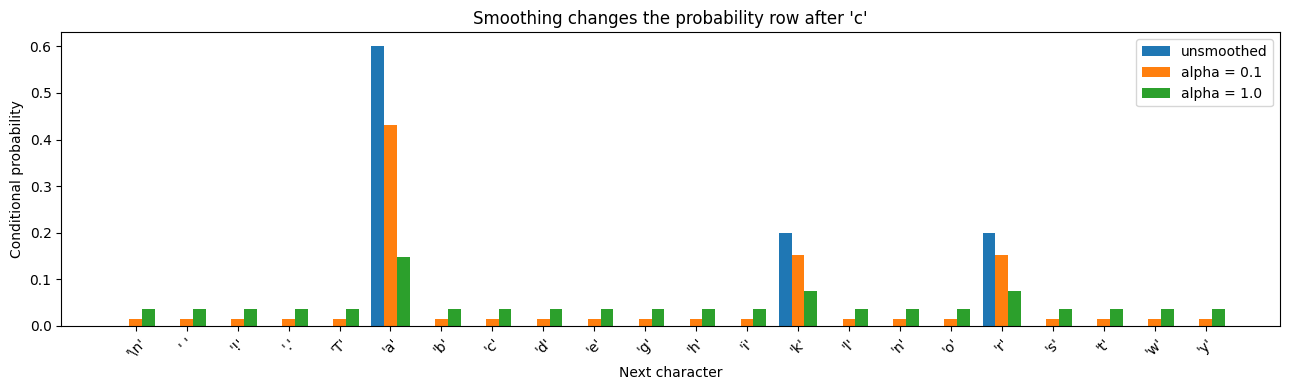

In [12]:
import matplotlib.pyplot as plt  # noqa: I001


positions = list(range(vocabulary_size))
labels = [repr(character) for character in character_vocabulary]
bar_width = 0.25

plt.figure(figsize=(13, 4))
plt.bar(
    [position - bar_width for position in positions],
    unsmoothed_row_for_c,
    width=bar_width,
    label="unsmoothed",
)
plt.bar(
    positions,
    add_point_one_row_for_c,
    width=bar_width,
    label="alpha = 0.1",
)
plt.bar(
    [position + bar_width for position in positions],
    add_one_row_for_c,
    width=bar_width,
    label="alpha = 1.0",
)
plt.xlabel("Next character")
plt.ylabel("Conditional probability")
plt.title("Smoothing changes the probability row after 'c'")
plt.xticks(positions, labels, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Smooth a Zero Row

A zero row becomes uniform because every adjusted count equals the same alpha.


In [13]:
zero_count_row = [0 for _ in range(vocabulary_size)]
smoothed_zero_row = normalize_with_add_alpha(zero_count_row, alpha=0.1)
uniform_probability = 1.0 / vocabulary_size

print("First five probabilities:", smoothed_zero_row[:5])
print("Expected uniform probability:", uniform_probability)
assert all(
    abs(probability - uniform_probability) < 1e-12 for probability in smoothed_zero_row
)

First five probabilities: [0.045454545454545456, 0.045454545454545456, 0.045454545454545456, 0.045454545454545456, 0.045454545454545456]
Expected uniform probability: 0.045454545454545456


Smoothing therefore handles zero rows directly, although a uniform row still contains no context-specific evidence.


## Smooth the Entire Count Table

Every count row can be passed through the same add-alpha normalization function.


In [14]:
def smooth_count_table(
    count_table: list[list[int]],
    alpha: float,
) -> list[list[float]]:
    if not count_table:
        raise ValueError("count_table cannot be empty.")
    expected_width = len(count_table[0])
    if expected_width == 0:
        raise ValueError("count_table rows cannot be empty.")
    if any(len(row) != expected_width for row in count_table):
        raise ValueError("All count rows must have the same width.")

    return [normalize_with_add_alpha(count_row, alpha) for count_row in count_table]


smoothed_table_point_one = smooth_count_table(bigram_count_table, alpha=0.1)
smoothed_table_one = smooth_count_table(bigram_count_table, alpha=1.0)

print(
    "alpha=0.1 shape:",
    (len(smoothed_table_point_one), len(smoothed_table_point_one[0])),
)
print("alpha=1.0 shape:", (len(smoothed_table_one), len(smoothed_table_one[0])))

alpha=0.1 shape: (22, 22)
alpha=1.0 shape: (22, 22)


## Verify Every Smoothed Row

Positive alpha gives every cell positive probability and every row total remains one.


In [15]:
for table in [smoothed_table_point_one, smoothed_table_one]:
    for probability_row in table:
        assert_valid_probability_distribution(probability_row)
        assert all(probability > 0 for probability in probability_row)

print("Every row is valid and every cell is positive.")

Every row is valid and every cell is positive.


## Compare Zero-Probability Cell Counts

The unsmoothed table needs a policy for any zero row, so we use unigram probabilities there exactly as Chapter 15 did.


In [16]:
def count_token_ids(token_ids: list[int], vocabulary_size: int) -> list[int]:
    counts = [0 for _ in range(vocabulary_size)]
    for token_id in token_ids:
        if not 0 <= token_id < vocabulary_size:
            raise ValueError(f"Invalid token ID {token_id}.")
        counts[token_id] += 1
    return counts


unigram_probabilities = normalize_without_smoothing(
    count_token_ids(token_ids, vocabulary_size)
)
unsmoothed_table = [
    normalize_without_smoothing(row) if sum(row) > 0 else unigram_probabilities.copy()
    for row in bigram_count_table
]


def count_zero_probability_cells(table: list[list[float]]) -> int:
    return sum(probability == 0 for row in table for probability in row)


print("Unsmoothed zeros:", count_zero_probability_cells(unsmoothed_table))
print("alpha=0.1 zeros:", count_zero_probability_cells(smoothed_table_point_one))
print("alpha=1.0 zeros:", count_zero_probability_cells(smoothed_table_one))
assert count_zero_probability_cells(smoothed_table_point_one) == 0
assert count_zero_probability_cells(smoothed_table_one) == 0

Unsmoothed zeros: 427
alpha=0.1 zeros: 0
alpha=1.0 zeros: 0


## Visualize the Smoothed Table

The heatmap uses alpha `0.1` so observed transitions remain visually prominent while every cell is positive.


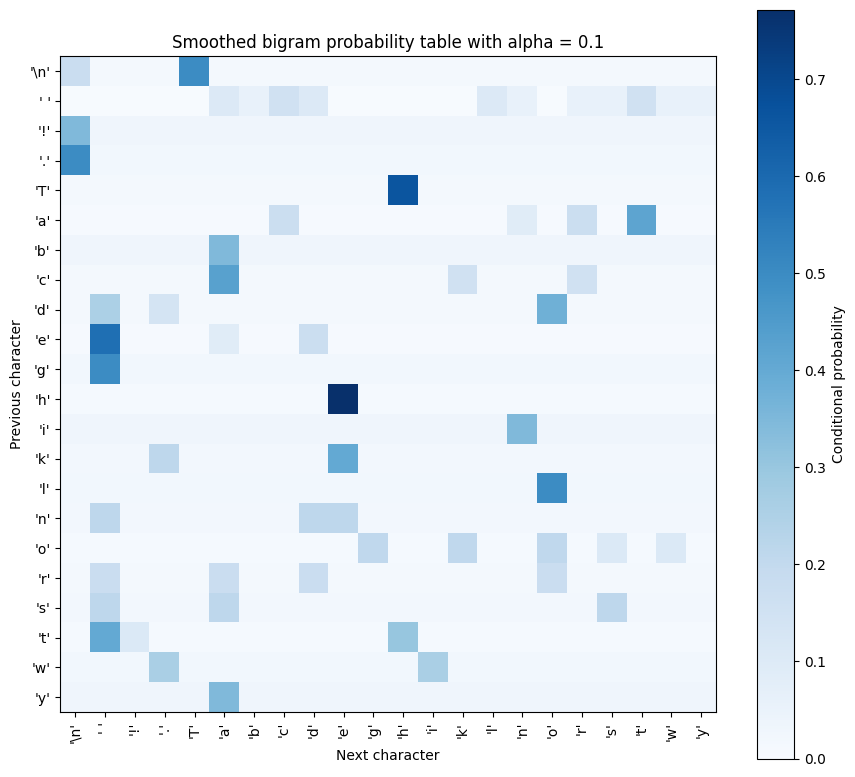

In [17]:
tick_positions = list(range(vocabulary_size))
tick_labels = [repr(character) for character in character_vocabulary]

plt.figure(figsize=(9, 8))
plt.imshow(smoothed_table_point_one, aspect="equal", cmap="Blues", vmin=0)
plt.xlabel("Next character")
plt.ylabel("Previous character")
plt.title("Smoothed bigram probability table with alpha = 0.1")
plt.xticks(tick_positions, tick_labels, rotation=90)
plt.yticks(tick_positions, tick_labels)
plt.colorbar(label="Conditional probability")
plt.tight_layout()
plt.show()

No cell is exactly zero, but observed transitions generally remain more probable than unseen transitions.


## Package the Smoothed Table as a Model

Every context row is valid after smoothing, while an empty or invalid context uses unigram probabilities.


In [18]:
class SmoothedBigramModel:
    def __init__(
        self,
        probability_table: list[list[float]],
        empty_context_probabilities: list[float],
    ):
        assert_valid_probability_distribution(empty_context_probabilities)
        for row in probability_table:
            assert_valid_probability_distribution(row)
        self.probability_table = probability_table
        self.empty_context_probabilities = empty_context_probabilities

    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> list[float]:
        if not input_token_ids:
            return self.empty_context_probabilities
        previous_token_id = input_token_ids[-1]
        if not 0 <= previous_token_id < len(self.probability_table):
            return self.empty_context_probabilities
        return self.probability_table[previous_token_id]


model_point_one = SmoothedBigramModel(
    smoothed_table_point_one,
    unigram_probabilities,
)
model_one = SmoothedBigramModel(
    smoothed_table_one,
    unigram_probabilities,
)

## Compare the Most Likely Prediction

Smoothing often preserves the most likely token while reducing its confidence.


In [19]:
def most_likely_token_id(probabilities: list[float]) -> int:
    assert_valid_probability_distribution(probabilities)
    return max(range(len(probabilities)), key=probabilities.__getitem__)


rows_to_compare = [
    ("unsmoothed", unsmoothed_row_for_c),
    ("alpha=0.1", add_point_one_row_for_c),
    ("alpha=1.0", add_one_row_for_c),
]

for name, row in rows_to_compare:
    best_id = most_likely_token_id(row)
    print(f"{name:<12}: {id_to_character[best_id]!r} at probability {row[best_id]:.6f}")

unsmoothed  : 'a' at probability 0.600000
alpha=0.1   : 'a' at probability 0.430556
alpha=1.0   : 'a' at probability 0.148148


## Sample and Generate

A fixed seed makes the stored generations reproducible across runs.


In [20]:
import random  # noqa: I001


RANDOM_SEED = 16


def sample_token_id(
    probabilities: list[float],
    random_generator: random.Random,
) -> int:
    assert_valid_probability_distribution(probabilities)
    return random_generator.choices(
        range(len(probabilities)),
        weights=probabilities,
        k=1,
    )[0]


def generate_text(
    model: SmoothedBigramModel,
    prompt: str,
    number_of_new_characters: int,
    character_to_id: dict[str, int],
    id_to_character: dict[int, str],
    random_seed: int,
) -> str:
    if number_of_new_characters < 0:
        raise ValueError("number_of_new_characters cannot be negative.")

    random_generator = random.Random(random_seed)
    generated_text = prompt
    for _ in range(number_of_new_characters):
        input_ids = encode_characters(generated_text, character_to_id)
        probabilities = model.predict_next_token_probabilities(input_ids)
        next_id = sample_token_id(probabilities, random_generator)
        generated_text += id_to_character[next_id]
    return generated_text


generated_point_one = generate_text(
    model_point_one,
    prompt="T",
    number_of_new_characters=160,
    character_to_id=character_to_id,
    id_to_character=id_to_character,
    random_seed=RANDOM_SEED,
)
generated_one = generate_text(
    model_one,
    prompt="T",
    number_of_new_characters=160,
    character_to_id=character_to_id,
    id_to_character=id_to_character,
    random_seed=RANDOM_SEED,
)

print("alpha=0.1:")
print(generated_point_one)
print()
print("alpha=1.0:")
print(generated_one)

alpha=0.1:
The g rat cackbnt wke inacahe dow.
wlok.
Thbin
inrdoke Td d.!he lwinicaca ow.drogbac
Tog d ke a.
Trd cacarogrok.
The d cacayarddoke rhe khe cat d heacat w
Teoog 

alpha=1.0:
Tecdearar
Td rbrwatoo
ckbacatahhwb ysrg. ce oo
reteneec
!Tgbhie.gwonrT! T
iw!lwoTiaa
et ag
doh  arwh!.c! eocssd.!lrsTh
Tc.
ybggedhe nknbenn cTleaceilagi w
i.wlal


Stronger smoothing usually looks more random because it allocates more probability to transitions unsupported by the observed bigrams.

Sample appearance alone is not enough to choose alpha, and later evaluation chapters will use held-out data for model comparison.


## Detect a Sampled Unseen Transition

Because smoothing makes every transition possible under the model, a generated sample can contain a pair absent from the training counts.


In [21]:
def unseen_transitions_in_text(
    text: str,
    count_table: list[list[int]],
    character_to_id: dict[str, int],
) -> list[tuple[str, str]]:
    unseen_transitions = []
    for previous_character, next_character in zip(text[:-1], text[1:], strict=True):
        previous_id = character_to_id[previous_character]
        next_id = character_to_id[next_character]
        if count_table[previous_id][next_id] == 0:
            unseen_transitions.append((previous_character, next_character))
    return unseen_transitions


generated_unseen_transitions = unseen_transitions_in_text(
    generated_point_one,
    bigram_count_table,
    character_to_id,
)

print("Number of sampled unseen transitions:", len(generated_unseen_transitions))
print("First ten:", generated_unseen_transitions[:10])

Number of sampled unseen transitions: 42
First ten: [(' ', 'g'), ('k', 'b'), ('b', 'n'), ('n', 't'), ('w', 'k'), (' ', 'i'), ('n', 'a'), ('a', 'h'), ('\n', 'w'), ('w', 'l')]


The generated transition is unseen in the fitted counts but still uses two characters already present in the vocabulary.


## Smoothing Does Not Add Vocabulary

Add-alpha smoothing redistributes probability only across existing vocabulary columns.


In [22]:
unknown_generated_characters = set(generated_point_one) - set(character_vocabulary)

print("Characters outside the vocabulary:", unknown_generated_characters)
assert not unknown_generated_characters

Characters outside the vocabulary: set()


## Smoothing Does Not Add Context

Two prompts ending in the same character still select the same row, regardless of their earlier characters.


In [23]:
contexts = ["The c", "abc"]
rows = [
    model_point_one.predict_next_token_probabilities(
        encode_characters(context, character_to_id)
    )
    for context in contexts
]

assert rows[0] == rows[1]
print("Contexts:", contexts)
print("Shared final character:", repr(contexts[0][-1]))
print("Predictions match:", rows[0] == rows[1])

Contexts: ['The c', 'abc']
Shared final character: 'c'
Predictions match: True


Smoothing changes values inside each row rather than increasing the model's one-token context length.


## See Strong Smoothing Approach Uniformity

On the toy row `[10, 0, 0]`, increasing alpha pulls the distribution toward equal probabilities.


In [24]:
toy_count_row = [10, 0, 0]

for alpha in [0.1, 1.0, 10.0, 1_000.0]:
    probability_row = normalize_with_add_alpha(toy_count_row, alpha)
    print(f"alpha={alpha:>6}: {probability_row}")

alpha=   0.1: [0.9805825242718446, 0.009708737864077669, 0.009708737864077669]
alpha=   1.0: [0.8461538461538461, 0.07692307692307693, 0.07692307692307693]
alpha=  10.0: [0.5, 0.25, 0.25]
alpha=1000.0: [0.33554817275747506, 0.33222591362126247, 0.33222591362126247]


Very strong smoothing can wash out useful observed patterns, which is the central tradeoff in choosing alpha.


## Complete Smoothing Pipeline

The final cell rebuilds a smoothed model with alpha `0.1`, verifies its invariants, and generates a deterministic sample.


In [25]:
final_vocabulary, final_character_to_id, final_id_to_character = (
    build_character_mappings(prepared_text)
)
final_token_ids = encode_characters(prepared_text, final_character_to_id)
final_count_table = build_bigram_count_table(
    final_token_ids,
    len(final_vocabulary),
)
final_alpha = 0.1
final_probability_table = smooth_count_table(final_count_table, final_alpha)
final_unigram_probabilities = normalize_without_smoothing(
    count_token_ids(final_token_ids, len(final_vocabulary))
)
final_model = SmoothedBigramModel(
    final_probability_table,
    final_unigram_probabilities,
)

for row in final_probability_table:
    assert_valid_probability_distribution(row)
    assert all(probability > 0 for probability in row)

final_generated_text = generate_text(
    final_model,
    prompt="T",
    number_of_new_characters=80,
    character_to_id=final_character_to_id,
    id_to_character=final_id_to_character,
    random_seed=RANDOM_SEED,
)

assert set(final_generated_text).issubset(set(final_vocabulary))
print("Vocabulary size:", len(final_vocabulary))
print("Smoothing alpha:", final_alpha)
print("Zero-probability cells:", count_zero_probability_cells(final_probability_table))
print("Generated text:", repr(final_generated_text))

Vocabulary size: 22
Smoothing alpha: 0.1
Zero-probability cells: 0
Generated text: 'The g rat cackbnt wke inacahe dow.\nwlok.\nThbin\ninrdoke Td d.!he lwinicaca ow.drog'


## Common Mistakes

- Treat zero count as unobserved data rather than proof of linguistic impossibility.

- Add alpha before normalizing, and include $\alpha V$ in the denominator.

- Remember that probability assigned to unseen transitions must reduce probability elsewhere.

- Do not assume add-one smoothing is always an appropriate strength.

- Do not use smoothing as a substitute for unknown-token handling.

- Do not confuse changed row probabilities with longer context.

- Evaluate smoothing choices on data not used to fit the counts when doing real model selection.


## Takeaways

Add-alpha smoothing transforms each row probability to $(C+\alpha)/(R+\alpha V)$.

Positive alpha gives every transition between known vocabulary tokens a positive model probability, including transitions absent from the training counts.

This robustness costs probability mass on observed transitions, and excessive smoothing pushes rows toward uniformity.

Smoothing neither expands the vocabulary nor increases the bigram model's context length.

The next chapter introduces log probabilities, which turn products of many small probabilities into sums and prepare us for more careful model evaluation.
